In [13]:
#Sequential workflow example
#Creating BMI calculator workflow 
from langgraph.graph import StateGraph,START,END
from typing import TypedDict

In [14]:
# Define state

class BMIState(TypedDict):
    weight_kg:float
    height_m:float
    bmi:float
    category:str


In [15]:
def calculate_bmi(state:BMIState) -> BMIState:
    weight=state["weight_kg"]
    height=state["height_m"]
    bmi=weight/(height**2)

    state["bmi"]= round(bmi,2)

    return state

In [16]:

def label_bmi(state:BMIState) -> BMIState:
    bmi=state['bmi']
    if bmi<18.5:
        state['category']="Underweight"
    elif 18.5<=bmi<25:
        state['category']="Normal weight"
    elif 25<=bmi<30:
        state['category']="Overweight"
    else:
        state['category']="Obese"
    return state

In [17]:
graph = StateGraph(BMIState)
#add nodes to graph
graph.add_node("calculate_bmi",calculate_bmi)
graph.add_node("label_bmi",label_bmi)
#add edge to graph
graph.add_edge(START,"calculate_bmi")
graph.add_edge("calculate_bmi","label_bmi")
graph.add_edge("label_bmi",END)

#compile graph
workflow=graph.compile()

#execute graph
initial_state={
    "weight_kg":90,
    "height_m":1.75
}

final_state=workflow.invoke(initial_state)
print(final_state)

{'weight_kg': 90, 'height_m': 1.75, 'bmi': 29.39, 'category': 'Overweight'}


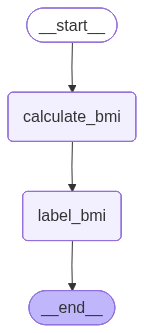

In [18]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())

### llm workflow

In [13]:
# llm workflow example
# START -> LLM_QA-> End 
# user asks a question, LLM answers it. This is a simple example of how to use LLMs in a workflow.
import os
from langchain_groq import ChatGroq
from dotenv import load_dotenv
load_dotenv()
API_KEY=os.getenv("API_KEY")

In [20]:
llm=ChatGroq(model_name="llama-3.3-70b-versatile",api_key=API_KEY)

In [21]:
class LLMState(TypedDict):
    question:str
    answer:str

In [22]:
def llm_qa(state:LLMState) -> LLMState:
    #extract question from state
    question=state["question"]
    #build prompt
    prompt=f"Answer the following question: {question}"
    #get answer from llm
    answer=llm.invoke(prompt).content
    #update state with answer
    state["answer"]=answer
    return state


In [23]:
graph = StateGraph(LLMState)
graph.add_node("LLM_QA",llm_qa)
graph.add_edge(START,"LLM_QA")
graph.add_edge("LLM_QA",END)

workflow=graph.compile()

In [24]:
initial_state={"question":"How far is moon from earth?"}

final_state=workflow.invoke(initial_state)

print(final_state['answer'])

The average distance from the Earth to the Moon is approximately 384,400 kilometers (238,900 miles). This distance is constantly changing due to the elliptical shape of the Moon's orbit around the Earth. At its closest point (called perigee), the Moon is about 356,400 kilometers (221,500 miles) away, and at its farthest point (apogee), it is about 405,500 kilometers (252,000 miles) away.


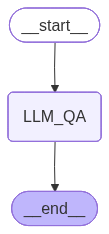

In [25]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())

### Prompt Chaining

In [26]:
# Prompt Chaining workflow example
# what happen in this: In this we call multiple LLMs in a sequence. 
# First we call one LLM to generate a prompt, then we call another LLM to answer the question based on 
# the generated prompt. 
# This is a common pattern in complex workflows where the output of one LLM is used as the input for another LLM.
# Example:
# we give topic to first LLM, it generate outline for the topic, then we gives this outline + topic to 
# another LLM to generate blog. 

# following is workflow for above example.
# Start -> Generate_Outline -> Generate_Blog -> End 

In [33]:
class Blogstate(TypedDict):
    title:str
    outline:str
    content:str
    evaluate:str
#first LLM to generate outline, second LLM to generate blog based on outline.
def create_outline(state:Blogstate) -> Blogstate:
    title=state["title"]
    prompt=f"Generate an outline for a blog post about {title}"
    outline=llm.invoke(prompt).content
    state["outline"]=outline
    return state

def create_blog(state:Blogstate) -> Blogstate:
    title=state["title"]
    outline=state["outline"]
    prompt=f"Write a blog post about {title} based on the following outline: {outline}"
    content=llm.invoke(prompt).content
    state["content"]=content
    return state
def evaluate_blog(state:Blogstate) -> Blogstate:
    title=state["title"]
    content=state["content"]
    prompt=f"Evaluate the following blog post about {title}: {content}"
    evaluation=llm.invoke(prompt).content
    state["evaluate"]=evaluation
    return state


In [34]:
graph=StateGraph(Blogstate)

graph.add_node("Generate_Outline",create_outline)
graph.add_node("Generate_Blog",create_blog)
graph.add_node("Evaluate_Blog",evaluate_blog)

graph.add_edge(START,"Generate_Outline")
graph.add_edge("Generate_Outline","Generate_Blog")
graph.add_edge("Generate_Blog","Evaluate_Blog")
graph.add_edge("Evaluate_Blog",END)

workflow=graph.compile()

In [35]:
initial_state={"title":"The future of AI in India"}
final_state=workflow.invoke(initial_state)
print(final_state['outline'])

Here is a suggested outline for a blog post on the future of AI in India:

**Title:** "The Future of AI in India: Opportunities, Challenges, and Predictions"

**I. Introduction**

* Brief overview of AI and its growing importance globally
* India's current stance on AI and its potential for growth
* Thesis statement: India is poised to become a major player in the global AI landscape, but it will require strategic investments, innovative approaches, and addressing unique challenges.

**II. Current State of AI in India**

* Overview of India's AI ecosystem, including key players, startups, and research institutions
* Discussion of current AI applications in India, such as:
	+ Chatbots and virtual assistants
	+ Image recognition and computer vision
	+ Natural Language Processing (NLP) and speech recognition
	+ Predictive analytics and machine learning
* Examples of successful AI implementations in Indian industries, such as healthcare, finance, and education

**III. Opportunities for AI 

In [36]:
print(final_state['content'])

**The Future of AI in India: Opportunities, Challenges, and Predictions**

As the world grapples with the rapidly evolving landscape of Artificial Intelligence (AI), India is poised to become a major player in the global AI landscape. With its growing economy, large talent pool, and increasing adoption of digital technologies, India has the potential to leverage AI to drive growth, innovation, and transformation across various sectors. In this blog post, we will explore the current state of AI in India, the opportunities and challenges that lie ahead, and make predictions for the future of AI in the country.

**Current State of AI in India**

India's AI ecosystem is rapidly evolving, with a growing number of startups, research institutions, and key players driving innovation and adoption. Currently, AI applications in India are being used in various industries, including chatbots and virtual assistants, image recognition and computer vision, Natural Language Processing (NLP) and speech

In [37]:
print(final_state['evaluate'])

**Evaluation of the Blog Post: "The Future of AI in India: Opportunities, Challenges, and Predictions"**

**Overall Assessment:**
The blog post provides a comprehensive overview of the current state of AI in India, highlighting the opportunities, challenges, and future predictions. The author presents a well-structured and informative analysis, making it an engaging read for both technical and non-technical audiences.

**Strengths:**

1. **Current State of AI in India:** The post provides a clear and concise overview of the current AI landscape in India, including the various industries that are leveraging AI and the applications being used.
2. **Opportunities for AI in India:** The author highlights the vast potential for AI in India, including emerging opportunities in agriculture, healthcare, education, and other sectors.
3. **Challenges Facing AI in India:** The post identifies the unique challenges facing AI adoption in India, such as data quality issues, infrastructure limitation

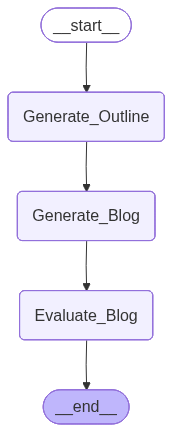

In [38]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())

#### Building ||er Workflow

In [1]:
# Building Parallel Workflow
# Workflow information : Calculate Strick rate,boundary percentage and balls per boundary for a cricket player.
    # States for this workflow:
    # 1.Runs 2. Balls 3. Boundaries 4. Strike Rate 5. Boundary Percentage 6. Balls per Boundary
    # in workflow we will calculate strike rate, boundary percentage and balls per boundary in parallel.
    # combine result in summary node. Summary node will take the output of all three parallel nodes and combine them into a single state.
                

In [2]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict

In [4]:
class BatsmanState(TypedDict):
    runs:int
    balls:int
    fours:int
    six:int

    sr:float #strick rate
    bpb:float #balls per boundary
    bp:float #boundary percentage
    summary:str 

In [8]:
def calculate_strick_rate(state:BatsmanState) :
    runs=state["runs"]
    balls=state["balls"]
    sr=(runs/balls)*100
    return {"sr":sr}

def calculate_bpb(state:BatsmanState) :# after how many balls players hit boundary
    bpb=(state["balls"])/(state["fours"]+state["six"])
    return {"bpb":bpb}

def calculate_bp(state:BatsmanState) : # percentage of boundary in total runs
    bp=((state["fours"]*4)+(state["six"]*6))/(state["runs"])*100
    return {"bp":bp}
    return state

def calculate_summary(state:BatsmanState) :
    summary= f"""
    Runs: {state['runs']}
    Balls: {state['balls']}
    Fours: {state['fours']}
    Sixes: {state['six']}
    Strike Rate: {state['sr']}
    Balls per Boundary: {state['bpb']}
    Boundary Percentage: {state['bp']}

"""
    return {"summary":summary}

In [9]:
graph=StateGraph(BatsmanState)

graph.add_node("calculate_strick_rate",calculate_strick_rate)
graph.add_node("calculate_bpb",calculate_bpb)
graph.add_node("calculate_bp",calculate_bp)
graph.add_node("calculate_summary",calculate_summary)

graph.add_edge(START,"calculate_strick_rate")
graph.add_edge(START,"calculate_bpb")
graph.add_edge(START,"calculate_bp")

graph.add_edge("calculate_strick_rate","calculate_summary")
graph.add_edge("calculate_bpb","calculate_summary")
graph.add_edge("calculate_bp","calculate_summary")

workflow=graph.compile()


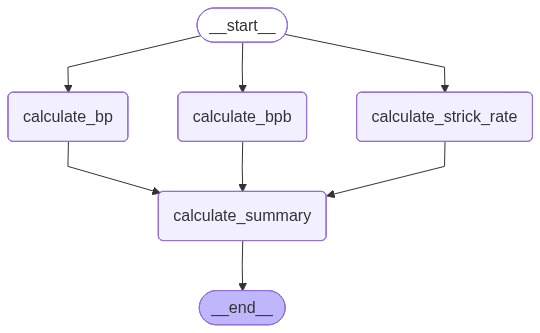

In [10]:
workflow

In [11]:
initial_state={
    "runs":120,
    "balls":100,
    "fours":10,
    "six":5
}

workflow.invoke(initial_state)


{'runs': 120,
 'balls': 100,
 'fours': 10,
 'six': 5,
 'sr': 120.0,
 'bpb': 6.666666666666667,
 'bp': 58.333333333333336,
 'summary': '\n    Runs: 120\n    Balls: 100\n    Fours: 10\n    Sixes: 5\n    Strike Rate: 120.0\n    Balls per Boundary: 6.666666666666667\n    Boundary Percentage: 58.333333333333336\n\n'}

In [ ]:
# Building UPSC essay evaluation workflow
# In this workflow we will evaluate an essay based on the following aspects:
    #1. Crearity of thoughts 2. Depth of analysis 3.language quality
    #this aspect will pass LLMs with same essay.
    #this LLM give output in : 1. Text feedback 2. Score out of 10
    # final evaluation will tell us summarized feedback and avge score of all three aspects.
# For an structured output from each node we predefine schema using pydantic

In [24]:
import os
from langchain_groq import ChatGroq
from pydantic import BaseModel,Field
from dotenv import load_dotenv
import operator
load_dotenv()
API_KEY=os.getenv("API_KEY")

In [15]:
llm=ChatGroq(model_name="llama-3.3-70b-versatile",api_key=API_KEY)

In [16]:
class EvaluationSchema(BaseModel):
    feedback:str=Field(description="Text feedback for the essay")
    score:int=Field(description="Score out of 10 for the essay",ge=0,le=10)

structured_output=llm.with_structured_output(EvaluationSchema)

In [32]:
essay="""
ust Walk on By: A Black Man Ponders His Power to Alter Public Space," Brent Staples explores the discrimination he faces as a Black man in predominantly white spaces. He recounts how his mere presence, particularly during late-night walks, often instills fear in others due to racial stereotypes. Staples argues that Black men are frequently misjudged and criminalized based solely on their appearance. To mitigate this fear and safely navigate public spaces, he explains that he now whistles classical music to signal his non-threatening, cultured nature.
"""

In [20]:
prompt=f"Evaluate language quality of following essay and provide feedback and score out of 10 \n {{essay}}"

structured_output.invoke(prompt).feedback

'The essay demonstrates a good command of language, with clear and concise sentences. However, there are some areas that need improvement, such as varying sentence structure and using more precise vocabulary. Additionally, there are a few grammatical errors that need to be corrected. Overall, the language quality is good, but could be improved with some revisions.'

In [25]:
# states of workflow
from typing import Annotated


class UPSCStates(TypedDict):
    essay:str
    language_feedback:str #language quality feedback by LLM
    analysis_feedback:str #Depth of analysis feedback by LLM
    clarity_feedback:str #Clarity of thought feedback by LLM

    overall_feedback:str #summarized feedback by final node
    individual_score:Annotated[list[int], operator.add] #individual score of all three aspects
    avg_score:float #average score of all three aspects

In [26]:
#first node
def evaluate_language_quality(state:UPSCStates):
    prompt=f'Evaluate language quality of following essay and provide feedback and score out of 10 \n {state["essay"]}'
    output=structured_output.invoke(prompt)

    return {
        "language_feedback":output.feedback,
        "individual_score":[output.score]
    }

#second node
def evaluate_Depth_of_analysis(state:UPSCStates):
    prompt=f'Evaluate depth of analysis of following essay and provide feedback and score out of 10 \n {state["essay"]}'
    output=structured_output.invoke(prompt)

    return {
        "analysis_feedback":output.feedback,
        "individual_score":[output.score]
    }

#third node
def evaluate_Clarity_of_thought(state:UPSCStates):
    prompt=f'Evaluate clarity of thought in following essay and provide feedback and score out of 10 \n {state["essay"]}'
    output=structured_output.invoke(prompt)

    return {
        "clarity_feedback":output.feedback,
        "individual_score":[output.score]
    }


#final node
def final_evaluation(state:UPSCStates):
    prompt=f"Based on the following feedback create a summarized feedback for the essay: \n Language Quality Feedback: {state['language_feedback']} \n Depth of Analysis Feedback: {state['analysis_feedback']} \n Clarity of Thought Feedback: {state['clarity_feedback']}"
    overall_feedback=llm.invoke(prompt).content

    avg_score=sum(state["individual_score"])/len(state["individual_score"])

    return{
        'overall_feedback':overall_feedback,
        'avg_score':avg_score
    }


In [29]:
graph=StateGraph(UPSCStates)
graph.add_node("evaluate_language_quality",evaluate_language_quality)
graph.add_node("evaluate_Depth_of_analysis",evaluate_Depth_of_analysis)
graph.add_node("evaluate_Clarity_of_thought",evaluate_Clarity_of_thought)
graph.add_node("final_evaluation",final_evaluation)

graph.add_edge(START,"evaluate_language_quality")
graph.add_edge(START,"evaluate_Depth_of_analysis")
graph.add_edge(START,"evaluate_Clarity_of_thought")

graph.add_edge('evaluate_language_quality',"final_evaluation")
graph.add_edge('evaluate_Depth_of_analysis',"final_evaluation")
graph.add_edge('evaluate_Clarity_of_thought',"final_evaluation")

graph.add_edge("final_evaluation",END)

workflow=graph.compile()

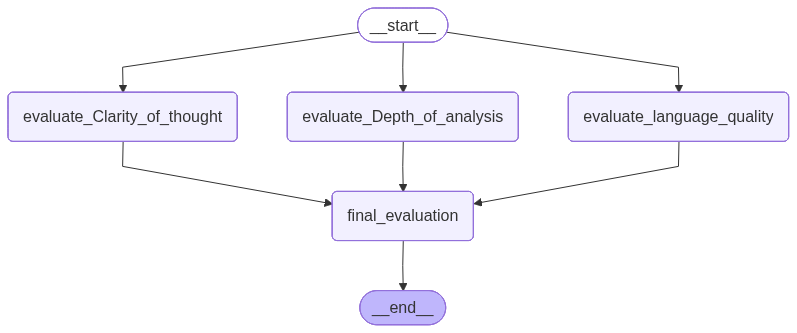

In [30]:
workflow

In [33]:
initial_state={
    'essay':essay
}

workflow.invoke(initial_state)

{'essay': '\nust Walk on By: A Black Man Ponders His Power to Alter Public Space," Brent Staples explores the discrimination he faces as a Black man in predominantly white spaces. He recounts how his mere presence, particularly during late-night walks, often instills fear in others due to racial stereotypes. Staples argues that Black men are frequently misjudged and criminalized based solely on their appearance. To mitigate this fear and safely navigate public spaces, he explains that he now whistles classical music to signal his non-threatening, cultured nature.\n',
 'language_feedback': "The essay provides a clear and concise summary of Brent Staples' experience with discrimination in predominantly white spaces. The language quality is good, with proper grammar and spelling. However, the essay could benefit from more nuanced analysis and critique of Staples' arguments. Additionally, the transition between sentences could be smoother, and more specific examples from the text could be 

### Conditional Workflow
- workflow is executed based on condition

In [34]:
# Quadratic Equation Solver Workflow
from langgraph.graph import START,END
from typing import TypedDict,Literal

In [35]:
class QuadState(TypedDict):
    a:int
    b:int
    c:int

    equation:str
    discriminant:int
    result:str


In [ ]:

def show_equation(state:QuadState):
    equation=f"{state['a']}x2{state['b']}x{state['c']}"

    return{'equation':equation}

def calculate_discriminant(state:QuadState):
    discriminant=state['b']**2-(4*state['a']*state['c'])

    return{'discriminant':discriminant}

def real_roots(state:QuadState):
    root1=(-state['b']+state['discriminant']**0.5)/(2*state['a'])
    root2=(-state['b']-state['discriminant']**0.5)/(2*state['a'])

    result=f'The roots are {root1} & {root2}'

    return {'result':result}

def repeated_roots(state:QuadState):
    root=(-state['b'])/(2*state['a'])

    result=f'only repeated root is {root}'

    return{'result':result}

def no_real_roots(state:QuadState):
    result=f'No real roots'
    return{'result':result}

def check_condition(state:QuadState)->Literal["real_roots","repeated_roots","no_real_roots"]:
    if state['discriminant']>0:
        return "real_roots"
    elif state['discriminant']==0:
        return "repeated_roots"
    else:
        return "no_real_roots"

In [41]:
graph=StateGraph(QuadState)

graph.add_node('show_equation',show_equation)
graph.add_node('calculate_discriminant',calculate_discriminant)
graph.add_node('real_roots',real_roots)
graph.add_node('repeated_roots',repeated_roots)
graph.add_node('no_real_roots',no_real_roots)

graph.add_edge(START,'show_equation')
graph.add_edge('show_equation','calculate_discriminant')
graph.add_conditional_edges('calculate_discriminant',check_condition)
graph.add_edge("real_roots",END)
graph.add_edge("repeated_roots",END)
graph.add_edge('no_real_roots',END)


workflow=graph.compile()

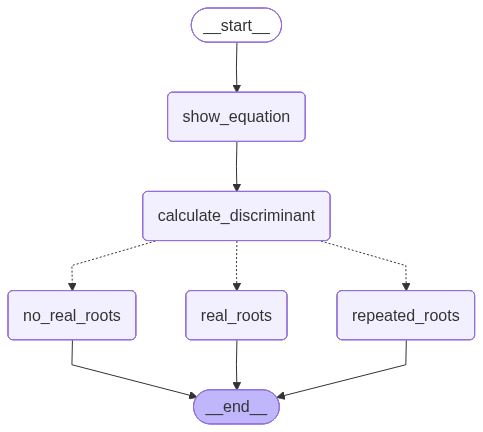

In [42]:
workflow

In [43]:
initial_state={
    'a':4,'b':-6,'c':-9
}

workflow.invoke(initial_state)

{'a': 4,
 'b': -6,
 'c': -9,
 'equation': '4x2-6x-9',
 'discriminant': 180,
 'result': 'The roots are 2.4270509831248424 & -0.9270509831248424'}

In [ ]:
# LLM Based review handeling workflow

# Workflow that provide the reply of customer review. First we compute sentiment of the review and based
# on that we write reply. 

# First we find the sentiment of the provided review via LLM. IF it is +ve than we send +ve reply 
# & end the flow else if -ve then we analyze diagnosis that -ve review via LLM i.e.,we analyze 1. which type of 
# issue is raised 2.Tone of the review 3.Urgency in the review 
# extract these 3 issuse and generate reply using LLM 

In [42]:
import os
from langgraph.graph import StateGraph,START,END
from langchain_groq import ChatGroq 
from typing import TypedDict,Literal
from pydantic import BaseModel,Field
from dotenv import load_dotenv

load_dotenv()

API_KEY=os.getenv('API_KEY')

In [43]:
model=ChatGroq(model_name="llama-3.3-70b-versatile",api_key=API_KEY)

In [44]:
class SentimentSchema(BaseModel):
    sentiment:Literal["Positive","Negative"]=Field(description="Sentiment of the review")

In [45]:
class DiagnosisSchema(BaseModel):
    issue_type:Literal['UX','Performance','Bug','Support','Others']=Field(description="The category of issue mention in the review")
    tone:Literal['angry','frustrated','disappointed','calm']=Field(description="The emotional tone express by the user")
    urgency:Literal['low','medium','high']=Field(description='How urgent or critical issue appers to be')

In [46]:
structured_output=model.with_structured_output(SentimentSchema)
structured_output2=model.with_structured_output(DiagnosisSchema)


In [48]:

prompt="What is sentiment of following review: The quality of software is too bad"

structured_output.invoke(prompt).sentiment

'Negative'

In [25]:
class ReviewState(TypedDict):
    review:str
    sentiment:Literal["Positive","Negative"]
    diagnosis:dict
    response:str

In [38]:

def find_sentiment(state:ReviewState):
    prompt=f'for the following review find out the sentiment \n {state['review']}'
    sentiment=structured_output.invoke(prompt).sentiment
    
    return {'sentiment':sentiment}

# conditional node
def check_sentiment(state:ReviewState)-> Literal["positive_response",'run_diagnosis']:
    if state['sentiment']=='Positive':
        return 'positive_response'
    else:
        return 'run_diagnosis'
    
def positive_response(state:ReviewState):
    prompt=f"""Write an warm thank-you message in response to this review:
    \n\n{state['review']}\n\n
    Also, kindly asked the user to leave feedback on our website."""
    response=model.invoke(prompt).content

    return {'response':response}
    
def run_diagnosis(state:ReviewState):
    prompt=f"""Diagnosis this negative review : \n\n{state['review']}\n.
    Return an issue type, tone and urgency"""

    response=structured_output2.invoke(prompt)
    return {'diagnosis':response.model_dump()}

def negative_response(state:ReviewState):
    diagnosis=state['diagnosis']

    prompt=f"""You are support assistant. 
    The user had {diagnosis['issue_type']} issue, sounded {diagnosis['tone']} , and marked urgerncy {diagnosis['urgency']}.
    Write an empathetic, helpful resolution message."""

    response=model.invoke(prompt).content

    return {'response':response}

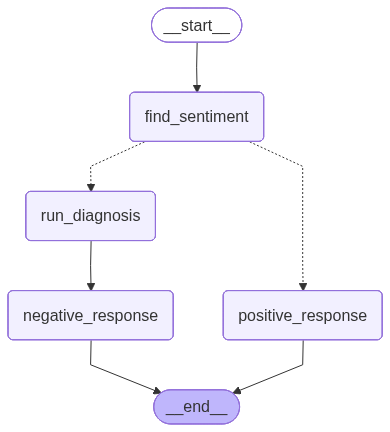

In [36]:
graph=StateGraph(ReviewState)

graph.add_node("find_sentiment",find_sentiment)
graph.add_node('positive_response',positive_response)
graph.add_node('run_diagnosis',run_diagnosis)
graph.add_node('negative_response',negative_response)


graph.add_edge(START,"find_sentiment")
graph.add_conditional_edges('find_sentiment',check_sentiment)
graph.add_edge('positive_response',END)
graph.add_edge('run_diagnosis','negative_response')
graph.add_edge('negative_response',END)

workflow=graph.compile()
workflow

In [40]:
initial_state={
    'review':"""Used to be great, but the new update ruined it. 
    The layout is chaotic, and it's impossible to find the logout button. 
    Please revert to the old version."""
}
workflow.invoke(initial_state)

{'review': "Used to be great, but the new update ruined it. \n    The layout is chaotic, and it's impossible to find the logout button. \n    Please revert to the old version.",
 'sentiment': 'Negative',
 'diagnosis': {'issue_type': 'UX', 'tone': 'frustrated', 'urgency': 'high'},
 'response': "I'm so sorry to hear that you're experiencing a frustrating UX issue. I can imagine how frustrating it must be, and I'm here to help you resolve it as quickly as possible.\n\nI've marked your issue as high priority, and I'll do my best to provide a solution or workaround to get you back on track. Please know that I'm committed to helping you, and I'll work diligently to ensure that your issue is addressed promptly.\n\nTo better understand the issue, could you please provide me with more details about what's happening? This will help me to provide a more accurate and effective solution. Additionally, if there's anything specific that you've tried so far, please let me know so I can avoid suggestin

### Itreative Workflows
- Social Media Post evaluation workflow

In [81]:
import os
from langgraph.graph import StateGraph,START,END
from langchain_groq import ChatGroq 
from typing import TypedDict,Literal
from pydantic import BaseModel,Field
from dotenv import load_dotenv
from langchain_core.messages import HumanMessage,SystemMessage

load_dotenv()

API_KEY=os.getenv('API_KEY')

In [82]:
generator_llm=ChatGroq(model_name='llama-3.3-70b-versatile',api_key=API_KEY)
evaluator_llm=ChatGroq(model_name='llama-3.3-70b-versatile',api_key=API_KEY)
optimizer_llm=ChatGroq(model_name='llama-3.3-70b-versatile',api_key=API_KEY)

In [83]:
class TweetState(TypedDict):
    topic:str
    tweet:str
    evaluation:Literal["approved","needs_improvement"]
    feedback:str
    iteration:int
    max_iteration:int

In [84]:
class TweetEvaluation(BaseModel):
    evaluation: Literal["approved", "needs_improvement"] = Field(..., description="Final evaluation result.")
    feedback: str = Field(..., description="feedback for the tweet.")



In [85]:
structured_evaluator=evaluator_llm.with_structured_output(TweetEvaluation)

In [86]:
def generate_tweet(state:TweetState):
    message=[
        SystemMessage(content="You are a funny and clever Twitter/X influencer."),
        HumanMessage(content=f"""Write a short, original, and hilarious tweet on the topic: "{state['topic']}".

            Rules:
            - Do NOT use question-answer format.
            - Max 280 characters.
            - Use observational humor, irony, sarcasm, or cultural references.
            - Think in meme logic, punchlines, or relatable takes.
            - Use simple, day to day english
            """)
    ]

    response=generator_llm.invoke(message).content
    return {"tweet":response}

def evaluate_tweet(state:TweetState):
    messages = [
    SystemMessage(content="You are a ruthless, no-laugh-given Twitter critic. You evaluate tweets based on humor, originality, virality, and tweet format."),
    HumanMessage(content=f"""
        Evaluate the following tweet:

        Tweet: "{state['tweet']}"

        Use the criteria below to evaluate the tweet:

        1. Originality – Is this fresh, or have you seen it a hundred times before?  
        2. Humor – Did it genuinely make you smile, laugh, or chuckle?  
        3. Punchiness – Is it short, sharp, and scroll-stopping?  
        4. Virality Potential – Would people retweet or share it?  
        5. Format – Is it a well-formed tweet (not a setup-punchline joke, not a Q&A joke, and under 280 characters)?

        Auto-reject if:
        - It's written in question-answer format (e.g., "Why did..." or "What happens when...")
        - It exceeds 280 characters
        - It reads like a traditional setup-punchline joke
        - Dont end with generic, throwaway, or deflating lines that weaken the humor (e.g., “Masterpieces of the auntie-uncle universe” or vague summaries)

        ### Respond ONLY in structured format:
        - evaluation: "approved" or "needs_improvement"  
        - feedback: One paragraph explaining the strengths and weaknesses 
        """)
        ]
    response=structured_evaluator.invoke(messages)

    return{'evaluation':response.evaluation,'feedback':response.feedback}


def optimize_tweet(state:TweetState):
    messages = [
        SystemMessage(content="You punch up tweets for virality and humor based on given feedback."),
        HumanMessage(content=f"""
        Improve the tweet based on this feedback:
        "{state['feedback']}"

        Topic: "{state['topic']}"
        Original Tweet:
        {state['tweet']}

        Re-write it as a short, viral-worthy tweet. Avoid Q&A style and stay under 280 characters.
        """)
    ]

    response=optimizer_llm.invoke(messages)

    iteration=state['iteration']+1

    return {'tweet':response,'iteration':iteration}

In [87]:
# iteration function

def route_evaluation(state:TweetState):
    if state['evaluation']=='approved' or state['iteration']>=state['max_iteration']:
        return 'approved'
    else:
        return 'needs_improvement'

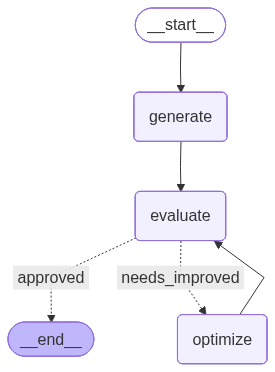

In [88]:
graph=StateGraph(TweetState)
graph.add_node("generate",generate_tweet)
graph.add_node("evaluate",evaluate_tweet)
graph.add_node("optimize",optimize_tweet)

graph.add_edge(START,'generate')
graph.add_edge('generate','evaluate')
graph.add_conditional_edges('evaluate',route_evaluation,{'approved':END,'needs_improved':'optimize'})
graph.add_edge('optimize','evaluate')

workflow=graph.compile()

workflow

In [99]:
initial_state = {
    "topic": "Indian Railway",
    "iteration": 1,
    "max_iteration": 5
}
result = workflow.invoke(initial_state)

In [100]:
result

{'topic': 'Indian Railway',
 'tweet': '"Indian Railway: where \'arrival time\' is just a suggestion and \'personal space\' is a myth" #IndianRailway',
 'evaluation': 'approved',
 'feedback': "This tweet is a great example of a well-crafted tweet that meets most of the criteria. The originality is high as it provides a fresh take on the Indian Railway experience. The humor is also well-executed, as it pokes fun at the common issues faced by commuters. The punchiness is excellent, with a short and sharp phrase that grabs attention. The virality potential is also high, as people who have experienced similar issues with Indian Railways may retweet or share it. The format is also well-done, as it's under 280 characters and doesn't follow a traditional setup-punchline joke structure. Overall, this tweet is scroll-stopping, relatable, and humorous, making it a great example of a tweet that could go viral.",
 'iteration': 1,
 'max_iteration': 5}